In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

# 딥러닝 : 데이터의 규칙성을 추출
- 응용분야 : 글자인식, 문장분류, 값예측, 질병진단, 얼굴인식
- ML/DL의 종류
    * 지도 학습(입력=독립변수, 타겟=종속변수)
        * 분류분석(타겟변수가 category변수인 분석) vs 회귀분석
    * 비지도학습(입력변수)
        * 군집화
    * 강화학습
    
- 지도학습에서의 딥러닝 프로그래밍 방식
    - 1. 데이터 확보 및 생성
    - 2. 데이터 전처리 : 결측치처리, 스캐일 조정, 인코딩처리(라벨 인코딩, 원핫인코딩), 학습, 검증, 시험데이터셋 분리
    - 3. 모델 구성
    - 4. 모델 학습 과정 설정
    - 5. 모델 학습시키기(훈련, 검증 데이터셋)
    - 6. 모델 평가(시험 데이터셋)
    - 7. 모델 저장/사용(입력값이 주어지면 예측값을 받기)

In [2]:
from tensorflow.keras.utils import to_categorical # 분류분석시 원핫인코딩(to_categorical추천)
import pandas as pd # 원핫인코딩
from tensorflow.keras.models import Sequential, load_model # 모델생성, 모델 load
from tensorflow.keras.layers import Dense,Input #모델에 층을 쌓기위해서
import numpy as np 

# 1. 데이터 셋 확보

# 2. 데이터 전처리

In [3]:
# 학습데이터 = 훈련데이터셋
x_train = np.array([1,2,3,4,5,6,7,8,9]*10)
y_train = np.array([2,3,4,5,6,7,8,9,10]*10)
# 검증데이터, 시험데이터셋
x_val = np.array([1,2,3,4,5,6,7,8,9])
y_val = np.array([2,3,4,5,6,7,8,9,10])

In [9]:
# 인코딩 종류
    # 라벨인코딩 = 문자를 숫자로
    # 원핫인코딩 = 값의 갯수만큼 열을 만들고, 해당 범주에 해당하는 열만 1을, 나머지 열은 0을
    
data = np.array(['aa','bb','cc','dd','ee'])
print('원데이터:',data)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# le.fit(data)
# labeling_data = le.transform(data)
labeling_data = le.fit_transform(data)
print('라벨인코딩된 데이터:',labeling_data)
onehot_encoding_data = to_categorical(labeling_data)
print('원핫인코딩된 데이터:\n', onehot_encoding_data)

onehot_encoding_data2 = pd.get_dummies(data)
print('원핫인코딩된 데이터:\n', onehot_encoding_data2)

원데이터: ['aa' 'bb' 'cc' 'dd' 'ee']
라벨인코딩된 데이터: [0 1 2 3 4]
원핫인코딩된 데이터:
 [[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]
원핫인코딩된 데이터:
    aa  bb  cc  dd  ee
0   1   0   0   0   0
1   0   1   0   0   0
2   0   0   1   0   0
3   0   0   0   1   0
4   0   0   0   0   1


In [11]:
data = np.array([1,2,3,4,5])
categorical_onehot = to_categorical(data)
print('to_categorical 이용\n',categorical_onehot)
getdummies_onehot = pd.get_dummies(data)
print('get_dummies 이용\n',getdummies_onehot)

to_categorical 이용
 [[0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]]
get_dummies 이용
    1  2  3  4  5
0  1  0  0  0  0
1  0  1  0  0  0
2  0  0  1  0  0
3  0  0  0  1  0
4  0  0  0  0  1


In [22]:
# 분류분석을 위한 종속(타겟)변수의 원핫인코딩
Y_train = to_categorical(y_train,11)
Y_val = to_categorical(y_val)

In [25]:
# 딥러닝 모델에 사용될 데이터
x_train.shape, Y_train.shape, x_val.shape, Y_val.shape

((90,), (90, 11), (9,), (9, 11))

# 3. 모델구성

In [27]:
model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(units=38,activation='sigmoid')) #활성화 함수 : relu,elu,tanh,sigmoid,softmax
model.add(Dense(64,activation='elu'))
model.add(Dense(32,activation='elu'))
model.add(Dense(11,activation='softmax')) #다중분류에서의 출력층 활성화 함수 : softmax
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 38)                76        
                                                                 
 dense_1 (Dense)             (None, 64)                2496      
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 11)                363       
                                                                 
Total params: 5,015
Trainable params: 5,015
Non-trainable params: 0
_________________________________________________________________


# 4. 모델학습과정설정
- 회기 분석에서의 loss : mse,mae,rmse
- 다중 분류에서의 loss : categorical_crossentropy
- 이진 분류에서의 loss : binary_crossentyopy
- 분류분석에서의 metrics(평가지표) : accuracy,recall,precision

In [30]:
model.compile(loss='categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])

# 5.모델 학습시키기

In [31]:
hist = model.fit(x_train,Y_train, # 학습데이터셋(입력변수와 타겟변수)
                epochs=300,       # 학습횟수
                batch_size=10,
                validation_data=(x_val,Y_val),
                verbose=1)
#verboss=0 : 학습로그출력없음/ 1:기본값출력 / 2:자세한 로그출력 

Epoch 1/300
9/9 [==============================] - 1s 57ms/step - loss: 2.4985 - accuracy: 0.0444 - val_loss: 2.3709 - val_accuracy: 0.1111
Epoch 2/300
9/9 [==============================] - 0s 8ms/step - loss: 2.3295 - accuracy: 0.1111 - val_loss: 2.2607 - val_accuracy: 0.1111
Epoch 3/300
9/9 [==============================] - 0s 9ms/step - loss: 2.2468 - accuracy: 0.1778 - val_loss: 2.1880 - val_accuracy: 0.2222
Epoch 4/300
9/9 [==============================] - 0s 8ms/step - loss: 2.1642 - accuracy: 0.2111 - val_loss: 2.1240 - val_accuracy: 0.2222
Epoch 5/300
9/9 [==============================] - 0s 8ms/step - loss: 2.1143 - accuracy: 0.2111 - val_loss: 2.0691 - val_accuracy: 0.3333
Epoch 6/300
9/9 [==============================] - 0s 7ms/step - loss: 2.0595 - accuracy: 0.2333 - val_loss: 2.0139 - val_accuracy: 0.2222
Epoch 7/300
9/9 [==============================] - 0s 8ms/step - loss: 2.0016 - accuracy: 0.2778 - val_loss: 1.9584 - val_accuracy: 0.3333
Epoch 8/300
9/9 [=========

9/9 [==============================] - 0s 8ms/step - loss: 0.0707 - accuracy: 1.0000 - val_loss: 0.0680 - val_accuracy: 1.0000
Epoch 118/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0698 - accuracy: 1.0000 - val_loss: 0.0670 - val_accuracy: 1.0000
Epoch 119/300
9/9 [==============================] - 0s 8ms/step - loss: 0.0665 - accuracy: 1.0000 - val_loss: 0.0643 - val_accuracy: 1.0000
Epoch 120/300
9/9 [==============================] - 0s 10ms/step - loss: 0.0651 - accuracy: 1.0000 - val_loss: 0.0625 - val_accuracy: 1.0000
Epoch 121/300
9/9 [==============================] - 0s 8ms/step - loss: 0.0622 - accuracy: 1.0000 - val_loss: 0.0601 - val_accuracy: 1.0000
Epoch 122/300
9/9 [==============================] - 0s 8ms/step - loss: 0.0601 - accuracy: 1.0000 - val_loss: 0.0584 - val_accuracy: 1.0000
Epoch 123/300
9/9 [==============================] - 0s 8ms/step - loss: 0.0592 - accuracy: 1.0000 - val_loss: 0.0573 - val_accuracy: 1.0000
Epoch 124/300
9/9 [=======

9/9 [==============================] - 0s 7ms/step - loss: 0.0061 - accuracy: 1.0000 - val_loss: 0.0060 - val_accuracy: 1.0000
Epoch 234/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0060 - accuracy: 1.0000 - val_loss: 0.0059 - val_accuracy: 1.0000
Epoch 235/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0060 - accuracy: 1.0000 - val_loss: 0.0059 - val_accuracy: 1.0000
Epoch 236/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0059 - accuracy: 1.0000 - val_loss: 0.0058 - val_accuracy: 1.0000
Epoch 237/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0058 - accuracy: 1.0000 - val_loss: 0.0057 - val_accuracy: 1.0000
Epoch 238/300
9/9 [==============================] - 0s 8ms/step - loss: 0.0057 - accuracy: 1.0000 - val_loss: 0.0056 - val_accuracy: 1.0000
Epoch 239/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0057 - accuracy: 1.0000 - val_loss: 0.0056 - val_accuracy: 1.0000
Epoch 240/300
9/9 [========

# 6. 모델 평가하기(모델 학습과정 살펴보고, evalute)

In [32]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

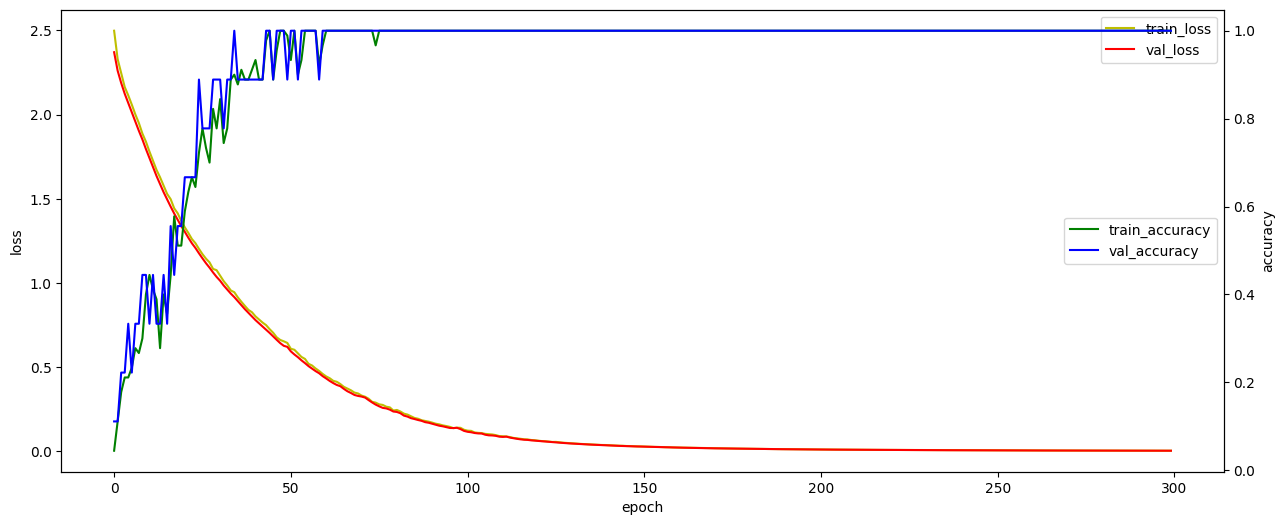

In [40]:
# 학습과정 살펴보기
import matplotlib.pyplot as plt
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'],'b',label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper right')
acc_ax.legend(loc='center right')

plt.show()

In [44]:
# 모델 평가하기
score = model.evaluate(x_val,Y_val,batch_size=3)
print('loss:',score[0])
print('accuracy:',score[1])

3/3 [==============================] - 0s 4ms/step - loss: 0.0027 - accuracy: 1.0000
loss: 0.002704438753426075
accuracy: 1.0


# 7. 모델 저장 

In [45]:
model.save('model/02_deep.h5')# 모델 저장 파일 : h5이나 keras

In [46]:
# 저장된 모델 사용하기
model = load_model('model/02_deep.h5')

# 7.모델사용

In [49]:
h = model.predict(np.array([6]))
h.argmax()

1/1 [==============================] - 0s 31ms/step


7

In [51]:
model.predict(np.array([5])).argmax()

1/1 [==============================] - 0s 32ms/step


6

In [52]:
# 몇%확률로 5라고 예측했나?
h[0,h.argmax()]*100

99.70972537994385

In [53]:
h[0,[5,6,7]]

array([6.0004064e-09, 1.0402285e-03, 9.9709725e-01], dtype=float32)